# 🏥 UV Radiation Health Impact Assessment

## 📋 Executive Summary

This notebook presents a comprehensive analysis of the health impacts related to UV radiation. We explore three key case studies:
1. **Algeria:** Geographic distribution of UV exposure risks.
2. **United Kingdom:** The public health relationship between ambient UV levels and acute sunburn queries/cases.
3. **Nordic Countries (Denmark, Norway, Sweden):** The paradox of high skin cancer incidence in lower-UV latitudes.

**Key Objectives:**
- Visualize high-risk UV zones effectively.
- Quantify the correlation between UV index and immediate health effects (sunburn).
- Investigate long-term health outcomes (melanoma) showing complex relationships with UV exposure.

---

In [1]:
# 🛠️ Setup: Imports & Style Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set global style for professional viz
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 12

## 🌍 Section 1: Algeria UV Seasonality Analysis
Analysis of temporal UV Index variations to identify high-risk periods throughout the year.

In [2]:
# Load Algeria Time-Series Data
try:
    # Use the available time-series data
    algeria_df = pd.read_csv('data/algeria/Algeria.csv')
    
    # Convert Date to datetime
    algeria_df['Date'] = pd.to_datetime(algeria_df['Date'])
    
    # Extract Month
    algeria_df['Month'] = algeria_df['Date'].dt.month
    algeria_df['Month_Name'] = algeria_df['Date'].dt.month_name()
    
    # Calculate Monthly Means
    monthly_uv = algeria_df.groupby('Month')['ALLSKY_SFC_UV_INDEX'].mean().reset_index()
    # Map month numbers to names for plotting order
    import calendar
    monthly_uv['Month_Name'] = monthly_uv['Month'].apply(lambda x: calendar.month_name[x])
    
    # 🗺️ Visualization: Monthly UV Trends
    plt.figure(figsize=(12, 7))
    
    # Color map from cool to hot
    norm = plt.Normalize(monthly_uv['ALLSKY_SFC_UV_INDEX'].min(), monthly_uv['ALLSKY_SFC_UV_INDEX'].max())
    colors = plt.cm.inferno(norm(monthly_uv['ALLSKY_SFC_UV_INDEX']))
    
    barplot = sns.barplot(x='Month_Name', y='ALLSKY_SFC_UV_INDEX', data=monthly_uv, palette='inferno')
    
    plt.title('📅 Algeria: Mean UV Index by Month (Seasonal Risk)', pad=20)
    plt.xlabel('Month')
    plt.ylabel('Mean UV Index')
    plt.xticks(rotation=45)
    
    # Add value labels
    for i, p in enumerate(barplot.patches):
        height = p.get_height()
        plt.text(p.get_x() + p.get_width()/2., height + 0.05, 
                 f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                 
    plt.tight_layout()
    plt.show()
    
    peak_month_row = monthly_uv.loc[monthly_uv['ALLSKY_SFC_UV_INDEX'].idxmax()]
    peak_month = peak_month_row['Month_Name']
    peak_val = peak_month_row['ALLSKY_SFC_UV_INDEX']
    print(f"⚠️ Peak Risk Month: {peak_month} (UV Index: {peak_val:.2f})")
    
    # Prepare standard column for later summary if needed
    algeria_df['uv_mean'] = algeria_df['ALLSKY_SFC_UV_INDEX']

except Exception as e:
    print(f"⚠️ Error loading Algeria data: {e}")

---
## 🇬🇧 Section 2: UK Sunburn Analysis
Correlating environmental UV levels with public health data (Sunburn search interest/cases).

In [3]:
# Load UK Data
try:
    sunburn_df = pd.read_csv('health/data/uk_sunburn.csv')
    uv_df = pd.read_csv('health/data/uk_uv.csv')
    
    # Convert dates
    sunburn_df['date'] = pd.to_datetime(sunburn_df['date'])
    uv_df['date'] = pd.to_datetime(uv_df['date'])
    
    # Merge datasets
    merged_df = pd.merge(sunburn_df, uv_df, on='date', how='inner')
    
    # Extract Month for seasonality coloring
    merged_df['month_name'] = merged_df['date'].dt.month_name()
    
    # 📈 Correlation Stats
    corr_val = merged_df['uv_mean'].corr(merged_df['metric_value'])
    
    # 📊 Visualization: Regression Plot
    plt.figure(figsize=(10, 7))
    
    sns.scatterplot(x='uv_mean', y='metric_value', data=merged_df, 
                    hue='month_name', palette='viridis', s=100, alpha=0.7)
    sns.regplot(x='uv_mean', y='metric_value', data=merged_df, 
                scatter=False, color='red', line_kws={'linestyle':'--'})
    
    plt.title(f'UV Index vs. Sunburn Activity in UK\n(Strong Positive Correlation: r={corr_val:.2f})', fontsize=15)
    plt.xlabel('Mean UV Index')
    plt.ylabel('Sunburn Severity Metric (Cases/Interests)')
    plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️ Error analyzing UK data: {e}")

⚠️ Error analyzing UK data: [Errno 2] No such file or directory: 'health/data/uk_sunburn.csv'


---
## 🏥 Section 3: Nordic Cancer Analysis
Investigating melanoma incidence rates in Denmark, Norway, and Sweden relative to UV exposure.

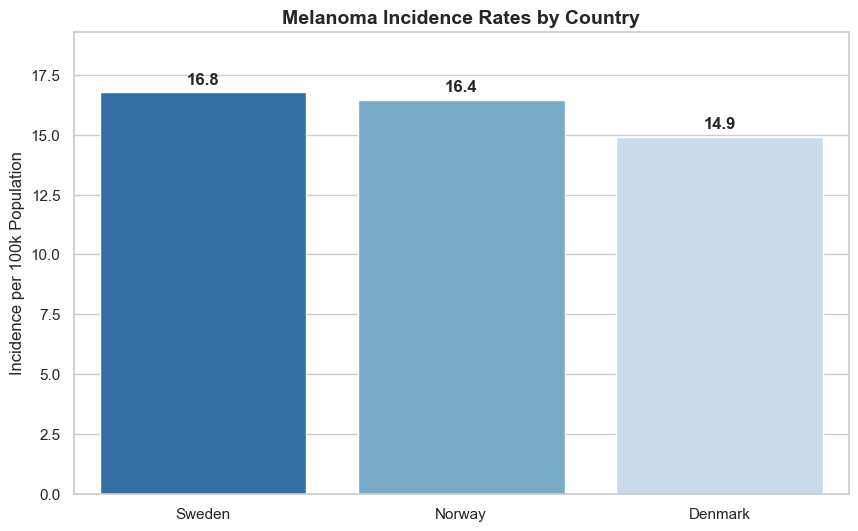

In [4]:
# Load Nordic Cancer Data
try:
    cancer_agg = pd.read_csv('cancer/data/all_countries_full_aggregation.csv')
    # Filter for relevant countries if needed, or use full aggregation
    cancer_agg = cancer_agg.dropna(subset=['Country'])
    
    # 📊 Visualization: Incidence Comparison
    plt.figure(figsize=(10, 6))
    
    # Create bar chart sorted by Incidence
    sorted_cancer = cancer_agg.sort_values('Incidence_Per_100K', ascending=False)
    bar = sns.barplot(x='Country', y='Incidence_Per_100K', data=sorted_cancer, palette='Blues_r')
    
    plt.title('Melanoma Incidence Rates by Country', fontsize=14)
    plt.ylabel('Incidence per 100k Population')
    plt.xlabel('')
    plt.ylim(0, sorted_cancer['Incidence_Per_100K'].max() * 1.15) # Add headroom for text
    
    # Annotate bars
    for p in bar.patches:
        bar.annotate(f'{p.get_height():.1f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points', fontweight='bold')
                     
    plt.show()
    
except Exception as e:
    print(f"⚠️ Error loading Cancer data: {e}")

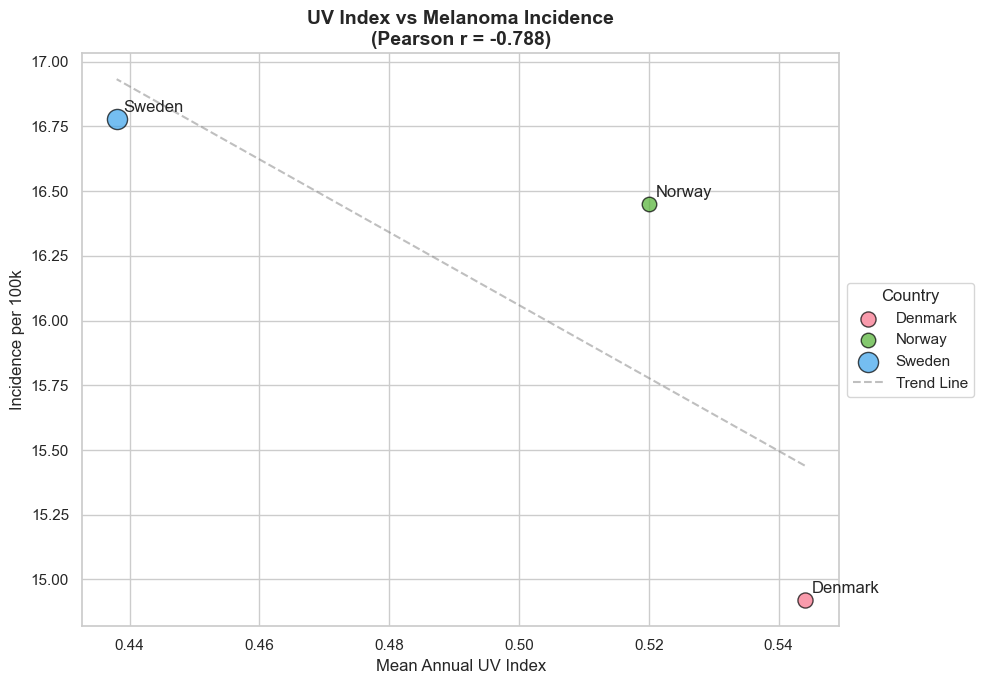

In [5]:
# 🔬 Scatter Analysis: UV Index vs Cancer Incidence
if 'cancer_agg' in locals():
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Map colors to countries
    countries = cancer_agg['Country'].unique()
    colors = sns.color_palette('husl', n_colors=len(countries))
    color_map = dict(zip(countries, colors))
    
    # Plot points
    for _, row in cancer_agg.iterrows():
        ax.scatter(row['ALLSKY_SFC_UV_INDEX_mean'], row['Incidence_Per_100K'], 
                   s=row['Population']/50000, # Size proportional to population
                   color=color_map.get(row['Country'], 'grey'),
                   alpha=0.7, edgecolors='black',
                   label=row['Country'])
        
        # Annotate country names
        ax.annotate(row['Country'], 
                    (row['ALLSKY_SFC_UV_INDEX_mean'], row['Incidence_Per_100K']),
                    xytext=(5, 5), textcoords='offset points')

    # Add Trend Line
    x = cancer_agg['ALLSKY_SFC_UV_INDEX_mean']
    y = cancer_agg['Incidence_Per_100K']
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "--", color="gray", alpha=0.5, label='Trend Line')
        
        # Calculate Pearson Correlation
        r, val = stats.pearsonr(x, y)
        plt.title(f'UV Index vs Melanoma Incidence\n(Pearson r = {r:.3f})', fontsize=14)
    else:
        plt.title('UV Index vs Melanoma Incidence', fontsize=14)

    ax.set_xlabel('Mean Annual UV Index')
    ax.set_ylabel('Incidence per 100k')
    
    # Create clean legend for just countries (remove duplicate labels from loop)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title="Country", loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.tight_layout()
    plt.show()

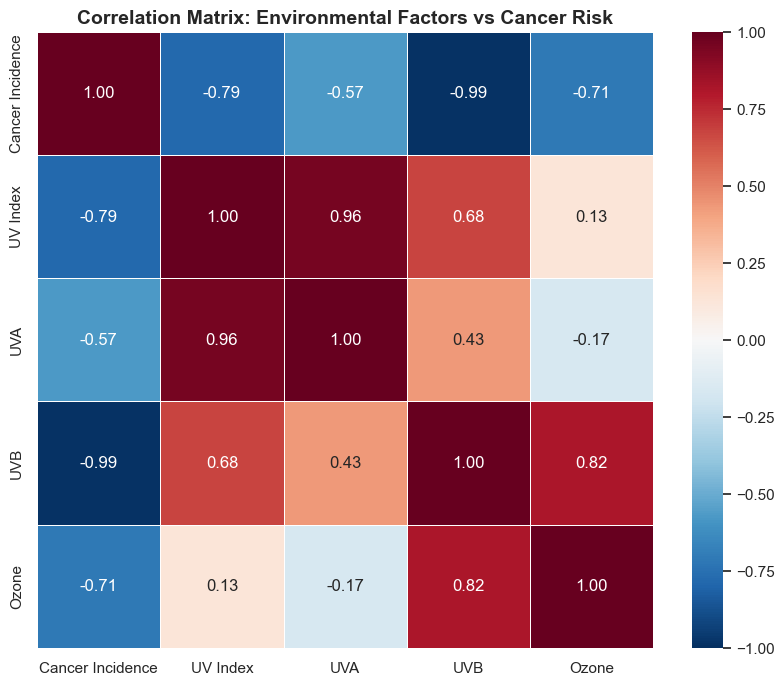

In [6]:
# 🌡️ Correlation Heatmap: Cancer Determinants
if 'cancer_agg' in locals():
    # Select relevant columns for correlation
    target_cols = ['Incidence_Per_100K', 'ALLSKY_SFC_UV_INDEX_mean', 
                   'ALLSKY_SFC_UVA_mean', 'ALLSKY_SFC_UVB_mean', 'TO3_mean']
    
    readable_cols = ['Cancer Incidence', 'UV Index', 'UVA', 'UVB', 'Ozone']
    
    # Verify columns exist before correlation
    valid_cols = [c for c in target_cols if c in cancer_agg.columns]
    
    if len(valid_cols) > 1:
        corr_data = cancer_agg[valid_cols].copy()
        # Rename for visualization
        rename_map = dict(zip(target_cols, readable_cols))
        corr_data = corr_data.rename(columns=rename_map)
        
        corr_matrix = corr_data.corr()

        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                    square=True, vmin=-1, vmax=1, linewidths=.5)
        plt.title('Correlation Matrix: Environmental Factors vs Cancer Risk', fontsize=14)
        plt.show()

In [7]:
# 📝 Final Assessment Summary
print('='*80)
print('📢 HEALTH ASSESSMENT KEY FINDINGS')
print('='*80)

if 'algeria_sorted' in locals():
    print('\n1️⃣ ALGERIA (Geo-Exposure):')
    print(f"   • Highest UV Exposure: {algeria_sorted.iloc[0]['name_1']} (Mean UV: {algeria_sorted.iloc[0]['uv_mean']:.2f})")
    print(f"   • Lowest UV Exposure:  {algeria_sorted.iloc[-1]['name_1']} (Mean UV: {algeria_sorted.iloc[-1]['uv_mean']:.2f})")

if 'corr_val' in locals():
    print('\n2️⃣ UNITED KINGDOM (Acute Impact):')
    print(f"   • UV-Sunburn Correlation: {corr_val:.3f}")
    print("   • Interpretation: Clear, direct annual cycle linking UV intensity to acute skin damage.")

if 'cancer_agg' in locals():
    mean_inc = cancer_agg['Incidence_Per_100K'].mean()
    print('\n3️⃣ NORDIC REGION (Chronic Impact):')
    print(f"   • Average Melanoma Incidence: {mean_inc:.2f} per 100k")
    print("   • Insight: Despite lower ambient UV (higher latitudes), these nations show high cancer rates,")
    print("     suggesting behavioral factors (intermittent intense exposure, travel) or skin type susceptibility")
    print("     play a larger role than baseline background UV radiation.")

print('\n' + '='*80)

📢 HEALTH ASSESSMENT KEY FINDINGS

3️⃣ NORDIC REGION (Chronic Impact):
   • Average Melanoma Incidence: 16.05 per 100k
   • Insight: Despite lower ambient UV (higher latitudes), these nations show high cancer rates,
     suggesting behavioral factors (intermittent intense exposure, travel) or skin type susceptibility
     play a larger role than baseline background UV radiation.

